In [29]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, HDBSCAN
from typing import Optional
import matplotlib.pyplot as plt
import plotly.express as px
from astropy.coordinates import SkyCoord
import astropy.units as u
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from typing import Iterable, Any, Dict, Iterable, Optional

plt.rcParams.update({
    "font.size": 20,        # tamaño base
    "axes.titlesize": 24,   # título del gráfico
    "axes.labelsize": 22,   # labels de ejes
    "xtick.labelsize": 18,  # números eje X
    "ytick.labelsize": 18,  # números eje Y
    "legend.fontsize": 18,  # leyenda
    "figure.titlesize": 26  # título general de la figura
})

In [20]:
def validate_columns(
    df: pd.DataFrame,
    required_columns: Iterable[str],
) -> None:
    """
    Validate that all required columns exist in a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    required_columns : Iterable[str]
        Required column names.

    Raises
    ------
    ValueError
        If one or more required columns are missing.
    """

    missing_columns = set(required_columns).difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{', '.join(sorted(missing_columns))}"
        )


def add_galactic_coordinates(
    df: pd.DataFrame,
    ra_col: str = "ra",
    dec_col: str = "dec",
    copy: bool = True,
) -> pd.DataFrame:
    """
    Add Galactic longitude and latitude to a Gaia-like DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    ra_col : str, optional
        Right ascension column in degrees.
    dec_col : str, optional
        Declination column in degrees.
    copy : bool, optional
        If True, returns a modified copy. If False, modifies in place.

    Returns
    -------
    pd.DataFrame
        DataFrame with added columns:
        - l
        - b
        - l_rad
        - b_rad
    """

    validate_columns(df, [ra_col, dec_col])

    result = df.copy() if copy else df

    coords = SkyCoord(
        ra=result[ra_col].to_numpy() * u.deg,
        dec=result[dec_col].to_numpy() * u.deg,
        frame="icrs",
    )

    galactic_coords = coords.galactic

    result["l"] = galactic_coords.l.degree
    result["b"] = galactic_coords.b.degree

    result["l_rad"] = np.radians(result["l"].to_numpy() - 180.0)
    result["b_rad"] = np.radians(result["b"].to_numpy())

    return result


def add_galactic_proper_motions(
    df: pd.DataFrame,
    ra_col: str = "ra",
    dec_col: str = "dec",
    pmra_col: str = "pmra",
    pmdec_col: str = "pmdec",
    copy: bool = True,
    include_mu_l: bool = False,
) -> pd.DataFrame:
    """
    Transform Gaia proper motions from ICRS coordinates to Galactic
    coordinates.

    Gaia provides:
    - pmra  = mu_alpha * cos(delta)
    - pmdec = mu_delta

    This function adds:
    - pm_l_cosb = mu_l * cos(b)
    - pm_b      = mu_b

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    ra_col : str, optional
        Right ascension column in degrees.
    dec_col : str, optional
        Declination column in degrees.
    pmra_col : str, optional
        Proper motion in right ascension, Gaia convention,
        in mas / yr.
    pmdec_col : str, optional
        Proper motion in declination in mas / yr.
    copy : bool, optional
        If True, returns a modified copy. If False, modifies in place.
    include_mu_l : bool, optional
        If True, also adds pm_l = pm_l_cosb / cos(b).
        For most clustering and kinematic applications, pm_l_cosb
        is preferred.

    Returns
    -------
    pd.DataFrame
        DataFrame with added columns:
        - pm_l_cosb
        - pm_b
        - optionally pm_l
    """

    required_columns = [ra_col, dec_col, pmra_col, pmdec_col]
    validate_columns(df, required_columns)

    result = df.copy() if copy else df

    coords = SkyCoord(
        ra=result[ra_col].to_numpy() * u.deg,
        dec=result[dec_col].to_numpy() * u.deg,
        pm_ra_cosdec=result[pmra_col].to_numpy() * u.mas / u.yr,
        pm_dec=result[pmdec_col].to_numpy() * u.mas / u.yr,
        frame="icrs",
    )

    galactic_coords = coords.galactic

    result["pm_l_cosb"] = galactic_coords.pm_l_cosb.to_value(
        u.mas / u.yr
    )
    result["pm_b"] = galactic_coords.pm_b.to_value(u.mas / u.yr)

    if include_mu_l:
        b_rad = galactic_coords.b.to_value(u.rad)
        cos_b = np.cos(b_rad)

        result["pm_l"] = np.where(
            np.abs(cos_b) > 1e-12,
            result["pm_l_cosb"].to_numpy() / cos_b,
            np.nan,
        )

    return result

In [23]:
MAS_TO_RAD = np.deg2rad(1.0 / 3_600_000.0)

In [24]:
def add_initial_final_galactic_vectors(
    df: pd.DataFrame,
    l_col: str = "l",
    b_col: str = "b",
    pm_l_col: str = "pm_l_cosb",
    pm_b_col: str = "pm_b",
    time_years: float = 1.0,
    angles_in_degrees: bool = True,
    pm_l_is_cosb: bool = True,
    copy: bool = True,
) -> pd.DataFrame:
    """
    Add initial and final unit-position vectors in Galactic coordinates.

    The initial position is computed as:

        x_i = cos(l) cos(b)
        y_i = sin(l) cos(b)
        z_i = sin(b)

    The final position is computed as:

        x_f = cos(l + mu_l t) cos(b + mu_b t)
        y_f = sin(l + mu_l t) cos(b + mu_b t)
        z_f = sin(b + mu_b t)

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    l_col : str, optional
        Galactic longitude column. Degrees by default.
    b_col : str, optional
        Galactic latitude column. Degrees by default.
    pm_l_col : str, optional
        Proper motion in Galactic longitude. By default this is assumed
        to be pm_l_cosb, i.e. mu_l * cos(b), in mas / yr.
    pm_b_col : str, optional
        Proper motion in Galactic latitude in mas / yr.
    time_years : float, optional
        Time interval used to propagate the position, in years.
    angles_in_degrees : bool, optional
        If True, l and b are interpreted as degrees. If False, radians.
    pm_l_is_cosb : bool, optional
        If True, pm_l_col is interpreted as pm_l_cosb = mu_l * cos(b).
        If False, pm_l_col is interpreted directly as mu_l.
    copy : bool, optional
        If True, returns a modified copy. If False, modifies in place.

    Returns
    -------
    pd.DataFrame
        DataFrame with added columns:
        - x_initial, y_initial, z_initial
        - x_final, y_final, z_final
        - l_final_rad, b_final_rad
        - delta_l_rad, delta_b_rad

    Raises
    ------
    ValueError
        If required columns are missing or if cos(b) is too close to zero
        when pm_l_is_cosb=True.
    """

    validate_columns(df, [l_col, b_col, pm_l_col, pm_b_col])

    result = df.copy() if copy else df

    if angles_in_degrees:
        l_rad = np.deg2rad(result[l_col].to_numpy(dtype=float))
        b_rad = np.deg2rad(result[b_col].to_numpy(dtype=float))
    else:
        l_rad = result[l_col].to_numpy(dtype=float)
        b_rad = result[b_col].to_numpy(dtype=float)

    pm_l_values = result[pm_l_col].to_numpy(dtype=float)
    pm_b_values = result[pm_b_col].to_numpy(dtype=float)

    cos_b = np.cos(b_rad)

    if pm_l_is_cosb:
        near_galactic_pole = np.abs(cos_b) < 1e-12

        if near_galactic_pole.any():
            raise ValueError(
                "Some sources have cos(b) too close to zero. "
                "Cannot safely compute mu_l = pm_l_cosb / cos(b)."
            )

        mu_l_masyr = pm_l_values / cos_b
    else:
        mu_l_masyr = pm_l_values

    mu_b_masyr = pm_b_values

    delta_l_rad = mu_l_masyr * MAS_TO_RAD * time_years
    delta_b_rad = mu_b_masyr * MAS_TO_RAD * time_years

    l_final_rad = l_rad + delta_l_rad
    b_final_rad = b_rad + delta_b_rad

    result["x_initial"] = np.cos(l_rad) * np.cos(b_rad)
    result["y_initial"] = np.sin(l_rad) * np.cos(b_rad)
    result["z_initial"] = np.sin(b_rad)

    result["x_final"] = np.cos(l_final_rad) * np.cos(b_final_rad)
    result["y_final"] = np.sin(l_final_rad) * np.cos(b_final_rad)
    result["z_final"] = np.sin(b_final_rad)

    result["delta_l_rad"] = delta_l_rad
    result["delta_b_rad"] = delta_b_rad
    result["l_final_rad"] = l_final_rad
    result["b_final_rad"] = b_final_rad

    return result

In [26]:
def add_cross_product_poles(
    df: pd.DataFrame,
    x_initial_col: str = "x_initial",
    y_initial_col: str = "y_initial",
    z_initial_col: str = "z_initial",
    x_final_col: str = "x_final",
    y_final_col: str = "y_final",
    z_final_col: str = "z_final",
    normalize: bool = True,
    copy: bool = True,
) -> pd.DataFrame:
    """
    Compute the cross product between initial and final unit-position
    vectors.

    The computed vector is:

        p = r_initial x r_final

    where:

        r_initial = (x_initial, y_initial, z_initial)
        r_final   = (x_final, y_final, z_final)

    This vector is normal to the great circle defined by the initial
    position and the proper-motion direction.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing initial and final Cartesian vectors.
    x_initial_col : str, optional
        Column name for initial x coordinate.
    y_initial_col : str, optional
        Column name for initial y coordinate.
    z_initial_col : str, optional
        Column name for initial z coordinate.
    x_final_col : str, optional
        Column name for final x coordinate.
    y_final_col : str, optional
        Column name for final y coordinate.
    z_final_col : str, optional
        Column name for final z coordinate.
    normalize : bool, optional
        If True, also adds normalized pole-vector columns.
    copy : bool, optional
        If True, returns a modified copy. If False, modifies in place.

    Returns
    -------
    pd.DataFrame
        DataFrame with added columns:
        - pole_x
        - pole_y
        - pole_z
        - pole_norm

        If normalize=True, also adds:
        - pole_x_unit
        - pole_y_unit
        - pole_z_unit
    """

    required_columns = [
        x_initial_col,
        y_initial_col,
        z_initial_col,
        x_final_col,
        y_final_col,
        z_final_col,
    ]

    validate_columns(df, required_columns)

    result = df.copy() if copy else df

    initial_vectors = result[
        [x_initial_col, y_initial_col, z_initial_col]
    ].to_numpy(dtype=float)

    final_vectors = result[
        [x_final_col, y_final_col, z_final_col]
    ].to_numpy(dtype=float)

    pole_vectors = np.cross(initial_vectors, final_vectors)

    result["pole_x"] = pole_vectors[:, 0]
    result["pole_y"] = pole_vectors[:, 1]
    result["pole_z"] = pole_vectors[:, 2]

    pole_norm = np.linalg.norm(pole_vectors, axis=1)
    result["pole_norm"] = pole_norm

    if normalize:
        valid_norm = pole_norm > 0.0

        normalized_poles = np.full_like(pole_vectors, np.nan)
        normalized_poles[valid_norm] = (
            pole_vectors[valid_norm] / pole_norm[valid_norm, None]
        )

        result["pole_x_unit"] = normalized_poles[:, 0]
        result["pole_y_unit"] = normalized_poles[:, 1]
        result["pole_z_unit"] = normalized_poles[:, 2]

    return result

In [30]:
def unit_vector_to_galactic_lb(vector: np.ndarray) -> Dict[str, float]:
    """
    Convert a 3D unit vector into Galactic longitude and latitude.

    Parameters
    ----------
    vector : np.ndarray
        Three-dimensional vector in Galactic Cartesian coordinates.

    Returns
    -------
    dict
        Dictionary with:
        - l_deg
        - b_deg
        - l_rad
        - b_rad
    """

    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)

    if norm == 0.0:
        raise ValueError("Input vector has zero norm.")

    unit_vector = vector / norm

    x_coord, y_coord, z_coord = unit_vector

    l_rad = np.arctan2(y_coord, x_coord) % (2.0 * np.pi)
    b_rad = np.arcsin(np.clip(z_coord, -1.0, 1.0))

    return {
        "l_deg": np.degrees(l_rad),
        "b_deg": np.degrees(b_rad),
        "l_rad": l_rad,
        "b_rad": b_rad,
    }


def estimate_apex_and_antapex(
    df: pd.DataFrame,
    pole_x_col: str = "pole_x_unit",
    pole_y_col: str = "pole_y_unit",
    pole_z_col: str = "pole_z_unit",
    x_initial_col: str = "x_initial",
    y_initial_col: str = "y_initial",
    z_initial_col: str = "z_initial",
    x_final_col: str = "x_final",
    y_final_col: str = "y_final",
    z_final_col: str = "z_final",
    weight_col: Optional[str] = None,
    orient_with_motion: bool = True,
    min_sources: int = 3,
) -> Dict[str, Any]:
    """
    Estimate the apex and antapex from great-circle pole vectors.

    The method fits the best great circle to the pole distribution.
    The apex is the unit vector normal to that great circle.

    Mathematically, for pole vectors p_i and apex vector A:

        p_i dot A ≈ 0

    The solution is obtained from the eigenvector associated with the
    smallest eigenvalue of the weighted covariance matrix of the poles.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing pole-vector columns.
    pole_x_col : str, optional
        Column name for the x component of the pole vector.
    pole_y_col : str, optional
        Column name for the y component of the pole vector.
    pole_z_col : str, optional
        Column name for the z component of the pole vector.
    x_initial_col : str, optional
        Column name for the initial x coordinate.
    y_initial_col : str, optional
        Column name for the initial y coordinate.
    z_initial_col : str, optional
        Column name for the initial z coordinate.
    x_final_col : str, optional
        Column name for the final x coordinate.
    y_final_col : str, optional
        Column name for the final y coordinate.
    z_final_col : str, optional
        Column name for the final z coordinate.
    weight_col : str or None, optional
        Optional column used as weights. For example, membership
        probability.
    orient_with_motion : bool, optional
        If True, uses the initial and final positions to decide which
        of the two opposite directions is the apex.
    min_sources : int, optional
        Minimum number of valid sources required.

    Returns
    -------
    dict
        Dictionary containing:
        - apex_vector
        - antapex_vector
        - apex_l_deg
        - apex_b_deg
        - antapex_l_deg
        - antapex_b_deg
        - n_sources
        - eigenvalues
        - rms_pole_residual_deg
        - median_pole_residual_deg
        - oriented_with_motion
        - toward_apex_fraction

    Raises
    ------
    ValueError
        If required columns are missing or not enough valid sources
        are available.
    """

    required_columns = [pole_x_col, pole_y_col, pole_z_col]

    if weight_col is not None:
        required_columns.append(weight_col)

    if orient_with_motion:
        required_columns.extend(
            [
                x_initial_col,
                y_initial_col,
                z_initial_col,
                x_final_col,
                y_final_col,
                z_final_col,
            ]
        )

    validate_columns(df, required_columns)

    pole_columns = [pole_x_col, pole_y_col, pole_z_col]
    poles = df[pole_columns].to_numpy(dtype=float)

    valid_mask = np.isfinite(poles).all(axis=1)
    pole_norms = np.linalg.norm(poles, axis=1)

    valid_mask &= pole_norms > 0.0

    if weight_col is not None:
        weights_all = df[weight_col].to_numpy(dtype=float)
        valid_mask &= np.isfinite(weights_all)
        valid_mask &= weights_all > 0.0
    else:
        weights_all = np.ones(len(df), dtype=float)

    if valid_mask.sum() < min_sources:
        raise ValueError(
            "Not enough valid sources to estimate apex. "
            f"Found {valid_mask.sum()}, required {min_sources}."
        )

    poles = poles[valid_mask]
    pole_norms = pole_norms[valid_mask]
    weights = weights_all[valid_mask]

    poles = poles / pole_norms[:, None]
    weights = weights / np.sum(weights)

    covariance_matrix = (poles * weights[:, None]).T @ poles

    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    smallest_index = np.argmin(eigenvalues)

    apex_vector = eigenvectors[:, smallest_index]
    apex_vector = apex_vector / np.linalg.norm(apex_vector)

    toward_apex_fraction = np.nan
    oriented = False

    if orient_with_motion:
        initial_columns = [x_initial_col, y_initial_col, z_initial_col]
        final_columns = [x_final_col, y_final_col, z_final_col]

        initial_vectors = df.loc[valid_mask, initial_columns].to_numpy(
            dtype=float
        )
        final_vectors = df.loc[valid_mask, final_columns].to_numpy(
            dtype=float
        )

        initial_norms = np.linalg.norm(initial_vectors, axis=1)
        final_norms = np.linalg.norm(final_vectors, axis=1)

        vector_valid = (initial_norms > 0.0) & (final_norms > 0.0)

        if vector_valid.sum() >= min_sources:
            initial_vectors = initial_vectors[vector_valid]
            final_vectors = final_vectors[vector_valid]
            orientation_weights = weights[vector_valid]

            initial_vectors = (
                initial_vectors / initial_norms[vector_valid, None]
            )
            final_vectors = final_vectors / final_norms[vector_valid, None]

            initial_projection = initial_vectors @ apex_vector
            final_projection = final_vectors @ apex_vector

            moving_toward_apex = final_projection > initial_projection

            toward_apex_fraction = np.average(
                moving_toward_apex.astype(float),
                weights=orientation_weights,
            )

            if toward_apex_fraction < 0.5:
                apex_vector = -apex_vector
                toward_apex_fraction = 1.0 - toward_apex_fraction

            oriented = True

    antapex_vector = -apex_vector

    apex_coordinates = unit_vector_to_galactic_lb(apex_vector)
    antapex_coordinates = unit_vector_to_galactic_lb(antapex_vector)

    pole_plane_residual = np.abs(poles @ apex_vector)
    pole_plane_residual = np.clip(pole_plane_residual, 0.0, 1.0)

    pole_residual_deg = np.degrees(np.arcsin(pole_plane_residual))

    rms_pole_residual_deg = np.sqrt(
        np.average(pole_residual_deg**2, weights=weights)
    )
    median_pole_residual_deg = np.median(pole_residual_deg)

    return {
        "apex_vector": apex_vector,
        "antapex_vector": antapex_vector,
        "apex_l_deg": apex_coordinates["l_deg"],
        "apex_b_deg": apex_coordinates["b_deg"],
        "apex_l_rad": apex_coordinates["l_rad"],
        "apex_b_rad": apex_coordinates["b_rad"],
        "antapex_l_deg": antapex_coordinates["l_deg"],
        "antapex_b_deg": antapex_coordinates["b_deg"],
        "antapex_l_rad": antapex_coordinates["l_rad"],
        "antapex_b_rad": antapex_coordinates["b_rad"],
        "n_sources": int(valid_mask.sum()),
        "eigenvalues": eigenvalues,
        "rms_pole_residual_deg": rms_pole_residual_deg,
        "median_pole_residual_deg": median_pole_residual_deg,
        "oriented_with_motion": oriented,
        "toward_apex_fraction": toward_apex_fraction,
    }

In [54]:
def galactic_lb_to_unit_vector(
    l_deg: float,
    b_deg: float,
) -> np.ndarray:
    """
    Convert Galactic longitude and latitude into a Cartesian unit vector.

    Parameters
    ----------
    l_deg : float
        Galactic longitude in degrees.
    b_deg : float
        Galactic latitude in degrees.

    Returns
    -------
    np.ndarray
        Cartesian unit vector (x, y, z).
    """

    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)

    return np.array(
        [
            np.cos(l_rad) * np.cos(b_rad),
            np.sin(l_rad) * np.cos(b_rad),
            np.sin(b_rad),
        ],
        dtype=float,
    )

def add_lambda_angle_from_apex(
    df: pd.DataFrame,
    apex_vector: Optional[np.ndarray] = None,
    apex_l_deg: Optional[float] = None,
    apex_b_deg: Optional[float] = None,
    x_col: str = "x_initial",
    y_col: str = "y_initial",
    z_col: str = "z_initial",
    copy: bool = True,
) -> pd.DataFrame:
    """
    Add the angular separation lambda between each star and the apex.

    Lambda is defined as:

        cos(lambda) = r_star dot A

    where r_star is the unit-position vector of the star and A is the
    unit vector pointing toward the apex.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing stellar unit-position vectors.
    apex_vector : np.ndarray or None, optional
        Cartesian unit vector of the apex. If provided, this is used
        directly.
    apex_l_deg : float or None, optional
        Galactic longitude of the apex in degrees. Used only if
        apex_vector is None.
    apex_b_deg : float or None, optional
        Galactic latitude of the apex in degrees. Used only if
        apex_vector is None.
    x_col : str, optional
        Column name for the x component of the stellar position vector.
    y_col : str, optional
        Column name for the y component of the stellar position vector.
    z_col : str, optional
        Column name for the z component of the stellar position vector.
    copy : bool, optional
        If True, returns a modified copy. If False, modifies in place.

    Returns
    -------
    pd.DataFrame
        DataFrame with added columns:
        - lambda_rad
        - lambda_deg
        - sin_lambda
        - cos_lambda

    Raises
    ------
    ValueError
        If required columns are missing, if the apex is not provided,
        or if invalid vectors are found.
    """

    validate_columns(df, [x_col, y_col, z_col])

    result = df.copy() if copy else df

    if apex_vector is None:
        if apex_l_deg is None or apex_b_deg is None:
            raise ValueError(
                "You must provide either apex_vector or both "
                "apex_l_deg and apex_b_deg."
            )

        apex_vector = galactic_lb_to_unit_vector(
            apex_l_deg=apex_l_deg,
            b_deg=apex_b_deg,
        )

    apex_vector = np.asarray(apex_vector, dtype=float)
    apex_norm = np.linalg.norm(apex_vector)

    if apex_norm == 0.0:
        raise ValueError("The apex vector has zero norm.")

    apex_unit = apex_vector / apex_norm

    star_vectors = result[[x_col, y_col, z_col]].to_numpy(dtype=float)
    star_norms = np.linalg.norm(star_vectors, axis=1)

    invalid_vectors = ~np.isfinite(star_vectors).all(axis=1)
    invalid_vectors |= star_norms == 0.0

    if invalid_vectors.any():
        raise ValueError(
            "Some stellar position vectors contain NaN, infinite values, "
            "or have zero norm."
        )

    star_unit_vectors = star_vectors / star_norms[:, None]

    cos_lambda = star_unit_vectors @ apex_unit
    cos_lambda = np.clip(cos_lambda, -1.0, 1.0)

    lambda_rad = np.arccos(cos_lambda)

    result["lambda_rad"] = lambda_rad
    result["lambda_deg"] = np.degrees(lambda_rad)
    result["sin_lambda"] = np.sin(lambda_rad)
    result["cos_lambda"] = cos_lambda

    return result

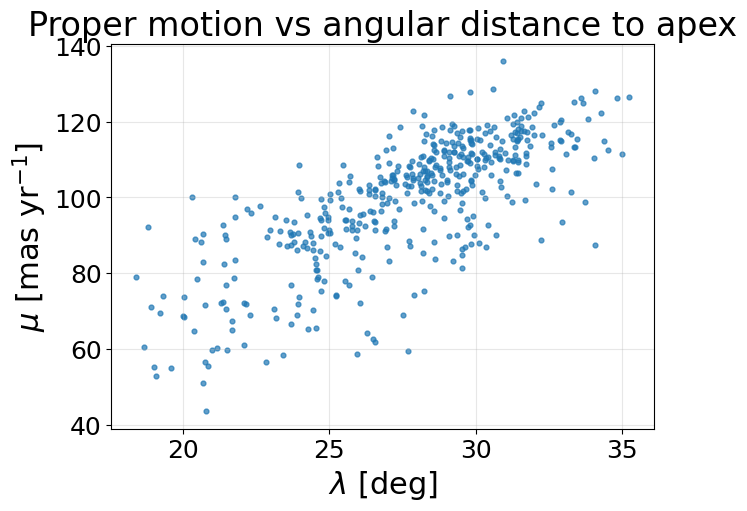

In [ ]:
df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_f00.csv")
# df = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\data\datos_resultados_modularizado\datos_clusterizados_todos_5d_trace.csv")
# df = df[df['grupo']>0]
df['division'] = df['coordenada_ra'].astype(str) + "_" + df['coordenada_dec'].astype(str)
# Convertir paralaje a distancia en parsecs
df['distance_pc'] = 1000 / df['parallax']  # pc

nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)
nueva_numeracion = np.arange(0,len(df['division'].unique()))
d_nueva_numeracion = dict(zip(df['division'].unique(),nueva_numeracion))
df['numeracion'] = df['division'].map(d_nueva_numeracion)
df['cluster'] = (df['grupo'].astype(str) + df['numeracion'].astype(str)).astype(int)
df["probabilidad"] = df["ConteoAgrupaciones"]/df["PresenteEnMuestras"]

df = df[df["cluster"]==8]

df = add_galactic_coordinates(df)
df = add_galactic_proper_motions(df)
df = add_initial_final_galactic_vectors(
    df,
    l_col="l",
    b_col="b",
    pm_l_col="pm_l_cosb",
    pm_b_col="pm_b",
    time_years=1.0,
    pm_l_is_cosb=True,
)
df = add_cross_product_poles(df)

# apex_result = estimate_apex_and_antapex(df)

# print("Apex:")
# print(apex_result["apex_l_deg"], apex_result["apex_b_deg"])

# print("Antapex:")
# print(apex_result["antapex_l_deg"], apex_result["antapex_b_deg"])

# print(
#     f"RMS residual: "
#     f"{apex_result['rms_pole_residual_deg']:.3f} deg"
# )

apex_result = estimate_apex_and_antapex(
    df,
    weight_col="probabilidad",
)

print(
    f"Apex: l={apex_result['apex_l_deg']:.3f} deg, "
    f"b={apex_result['apex_b_deg']:.3f} deg"
)

print(
    f"Antapex: l={apex_result['antapex_l_deg']:.3f} deg, "
    f"b={apex_result['antapex_b_deg']:.3f} deg"
)
s
print(
    f"RMS residual: "
    f"{apex_result['rms_pole_residual_deg']:.3f} deg"
)

df = add_lambda_angle_from_apex(
    df,
    apex_vector=apex_result["apex_vector"],
)
# df = add_lambda_angle_from_apex(
#     df,
#     apex_l_deg=apex_result["apex_l_deg"],
#     apex_b_deg=apex_result["apex_b_deg"],
# )
df["pm_total"] = np.sqrt(
    df["pm_l_cosb"] ** 2 + df["pm_b"] ** 2
)
df

plt.figure(figsize=(7, 5))

plt.scatter(
    df["lambda_deg"],
    df["pm_total"],
    s=12,
    alpha=0.7,
)

plt.xlabel(r"$\lambda$ [deg]")
plt.ylabel(r"$\mu$ [mas yr$^{-1}$]")
plt.title("Proper motion vs angular distance to apex")
plt.grid(alpha=0.3)
plt.show()

In [13]:
df

,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,...,division,distance_pc,x_pc,y_pc,z_pc,probabilidad,l,b,l_rad,b_rad
0,2674999,6040078002335401088,241.821543,-29.973880,24.489880,-61.098367,-117.029628,1.791729,12.010539,2.224945,...,240_-30,40.833193,-16.703290,-31.179648,-20.400473,0.000000,345.797541,16.162664,2.893713,0.282092
1,2675006,6040134970776529280,240.839038,-29.753550,13.704637,-74.007513,-62.129096,1.092193,18.539207,3.889986,...,240_-30,72.968005,-30.867490,-55.319341,-36.211854,0.000000,345.318221,16.913254,2.885347,0.295192
2,2676355,6038739175123702656,243.408989,-29.056985,10.106344,-58.229158,-14.992815,3.833167,7.413763,0.736953,...,240_-30,98.947752,-38.716295,-77.344963,-48.056871,0.000000,347.488355,15.835118,2.923223,0.276375
3,2676358,6039138847603948416,243.396294,-28.627859,10.078718,-96.598131,52.801011,5.285204,12.072105,1.416434,...,240_-30,99.218966,-39.000134,-77.868886,-47.537663,0.000000,347.799357,16.143160,2.928651,0.281751
4,2677357,6042493972972455936,242.197659,-27.582633,30.183779,-230.203369,-130.698523,2.882674,14.074344,2.775201,...,240_-30,33.130378,-13.696463,-25.975082,-15.340273,0.035714,347.800868,17.629869,2.928678,0.307699
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398945,7658651,6053513553433287680,186.865444,-63.953566,10.382718,-10.895039,-10.904614,1.627862,20.489765,2.369421,...,180_-90,96.313890,-41.988127,-5.055429,-86.532105,0.000000,300.303244,-1.204258,2.099688,-0.021018
398946,7658681,6053603335398471552,189.490148,-63.408100,14.480820,-156.042102,21.383837,1.162872,13.715505,2.496366,...,180_-90,69.056862,-30.489044,-5.096727,-61.751856,0.000000,301.424322,-0.575810,2.119254,-0.010050
398947,7658697,6053715142009729792,185.850779,-63.586183,10.883289,3.745445,7.814095,1.114863,20.546808,NaN,...,180_-90,91.883985,-40.661773,-4.166684,-82.291711,0.000000,299.819967,-0.883955,2.091253,-0.015428
398948,7659968,6053748539641950336,186.958183,-63.299673,10.471130,-5.715783,-17.756355,1.584388,20.574495,2.224798,...,180_-90,95.500676,-42.594710,-5.198419,-85.317327,0.000000,300.283953,-0.549353,2.099351,-0.009588
